# データサイエンス特論 第10回 事前課題
青山学院大学大学院 理工学研究科 理工学専攻 知能情報コース 修士1年 35626302 森下剛

In [5]:
import random
import numpy as np
import matplotlib.pyplot as plt

### 次元の呪い

#### 事前課題1の解答

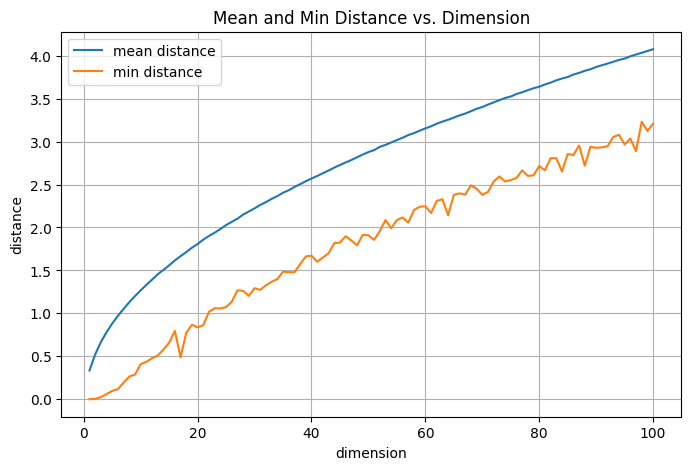

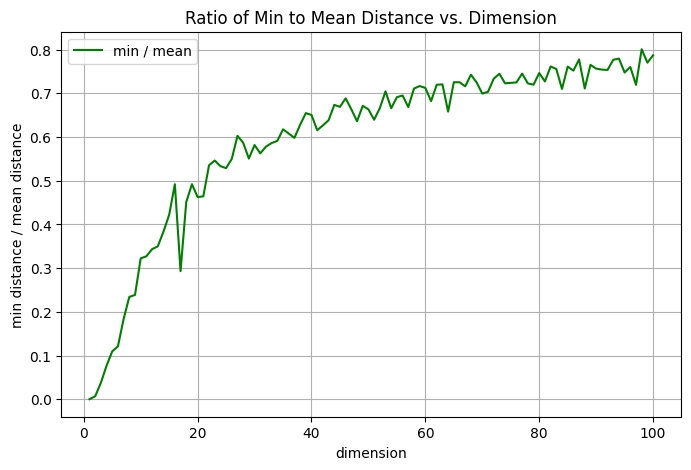

In [6]:
def random_point(d):
    return np.array([random.random() for _ in range(d)])


n_pairs = 10000
dims = range(1, 101)

mean_dists = []
min_dists = []

for d in dims:
    # 10000組の点ペアそれぞれについてユークリッド距離を計算
    dists = np.empty(n_pairs)
    for i in range(n_pairs):
        p = random_point(d)
        q = random_point(d)
        dists[i] = np.linalg.norm(p - q)
    mean_dists.append(dists.mean())
    min_dists.append(dists.min())

mean_dists = np.array(mean_dists)
min_dists = np.array(min_dists)
ratio = min_dists / mean_dists

# 平均距離と最小距離の変化
plt.figure(figsize=(8, 5))
plt.plot(dims, mean_dists, label="mean distance")
plt.plot(dims, min_dists, label="min distance")
plt.xlabel("dimension")
plt.ylabel("distance")
plt.title("Mean and Min Distance vs. Dimension")
plt.legend()
plt.grid(True)
plt.show()

# 最小距離÷平均距離の変化
plt.figure(figsize=(8, 5))
plt.plot(dims, ratio, color="green", label="min / mean")
plt.xlabel("dimension")
plt.ylabel("min distance / mean distance")
plt.title("Ratio of Min to Mean Distance vs. Dimension")
plt.legend()
plt.grid(True)
plt.show()


**平均距離に関する考察**
- 次元の増加に従って $\sqrt{d}$ 的に増加する。

**最小距離に関する考察**
- 低次元ではほとんど0である。
- 次元が増えると急速に増加し、平均距離と同じように $\sqrt{d}$ 的な挙動を呈する。

**平均距離と最小距離の比に関する考察**
- 次元が増えるごとに0.8に近い部分に収束していくことが確認できる。
- これは次元増加に伴って最小距離と平均距離の差が相対的に縮まり、サンプルされる点ペア同士の距離がどれも等しくなることを意味する。

**得られる知見**
- 高次元では近傍距離と平均距離の差がほとんどなくなるため、距離の大小での意味が薄れてくる。
- よって、高次元では距離に依存する手法（k近傍法、距離ベースのクラスタリング）は高次元で機能しにくくなることがわかる。


### 主成分分析

#### 事前課題2の解答

**scikit-learn PCA の調査**
- データの分散が最も大きくなる方向（主成分）を順番に見つけ出し、元の属性をそれらの主成分で表現し直すことで次元を削減する手法である。互いに相関の少ない少数の軸へ情報をまとめ直すことができる。
- PCA のインスタンスを作り、fit_transform() にデータを渡すことで、主成分で表現し直したデータが返ってくる。
- explained_variance_ratio_ で各主成分が元のデータの分散をどれだけ説明しているかを確認できる。

引数は以下の通りである。
- n_components：残す主成分の数を指定する。0〜1の小数を与えると、その割合の分散を説明できるだけの主成分数が自動で選ばれる。
- whiten：主成分の分散を揃えるかどうかを指定する。
- svd_solver：特異値分解の計算方法を指定する。
- random_state：乱数を用いる計算における再現性を確保するための値を指定する。


### 属性選択

#### 事前課題3の解答

**scikit-learn SelectKBest の調査**

多くの属性の中から、目的変数との関連が強い属性を上位 k 個だけ選び出す属性選択の手法である。あらかじめ指定したスコア関数で各属性の重要度を評価し、スコアの高いものから k 個を残す。
- SelectKBest のインスタンスを作り、fit_transform() に属性データと目的変数を渡すと、選ばれた k 個の属性だけからなるデータが返ってくる
- どの属性が選ばれたかは get_support() で確認できる。

引数は以下の通りである。
- score_func：各属性の重要度を評価するスコア関数を指定する。分類では f_classif や chi2、回帰では f_regression を用いる。
- k：残す属性の数を指定する。all を指定するとすべての属性が残る。
